## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv("crop_yield.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Crop,State,Area,Rainfall,Temperature,Fertilizer,Pesticide,Yield
0,Cotton,Punjab,9.99,725.82,33.11,83.50,21.26,1.43
1,Maize,Punjab,48.53,761.30,24.59,136.94,13.15,3.85
2,Cotton,Karnataka,26.71,374.01,27.31,81.77,23.89,1.61
3,Maize,Maharashtra,26.20,595.79,24.37,127.44,10.40,3.92
4,Wheat,Maharashtra,47.17,395.99,25.80,125.58,7.60,3.61


## 3. Understand the Dataset

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (500, 8)

Column Names:
Index(['Crop', 'State', 'Area', 'Rainfall', 'Temperature', 'Fertilizer',
       'Pesticide', 'Yield'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop         500 non-null    object 
 1   State        500 non-null    object 
 2   Area         500 non-null    float64
 3   Rainfall     500 non-null    float64
 4   Temperature  500 non-null    float64
 5   Fertilizer   500 non-null    float64
 6   Pesticide    500 non-null    float64
 7   Yield        500 non-null    float64
dtypes: float64(6), object(2)
memory usage: 31.4+ KB


In [4]:
df.describe()

,Area,Rainfall,Temperature,Fertilizer,Pesticide,Yield
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,26.044680,904.806600,26.534240,128.921000,17.58112,4.364000
std,14.303647,288.153226,3.180183,31.447285,6.16396,1.893641
min,1.260000,250.000000,17.210000,53.130000,2.32000,1.330000
25%,14.097500,670.250000,24.237500,105.342500,13.42000,3.180000
50%,26.725000,883.355000,26.570000,127.365000,17.01500,4.060000
75%,38.227500,1127.807500,28.672500,152.177500,21.30500,4.905000
max,49.950000,1662.840000,37.850000,228.020000,35.89000,8.100000


## 4. Check Missing Values

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Crop           0
State          0
Area           0
Rainfall       0
Temperature    0
Fertilizer     0
Pesticide      0
Yield          0
dtype: int64


## 5. Data Cleaning

In [6]:
df = df.dropna()
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (500, 8)


## 6. Basic Data Visualization

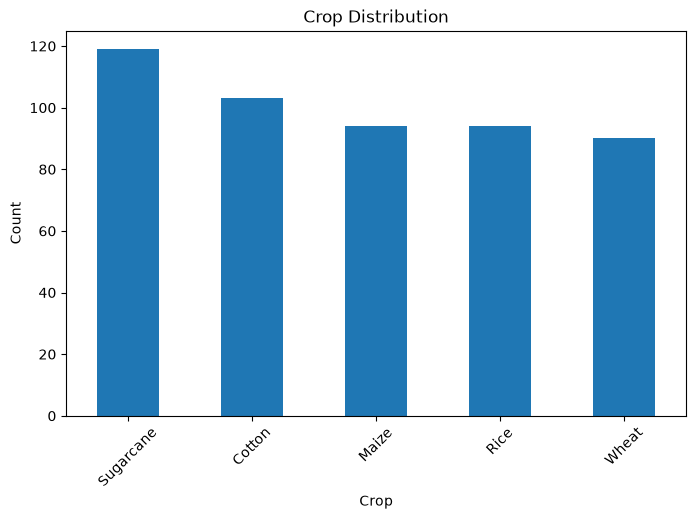

In [7]:
crop_counts = df["Crop"].value_counts()

plt.figure(figsize=(8,5))
crop_counts.plot(kind="bar")
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

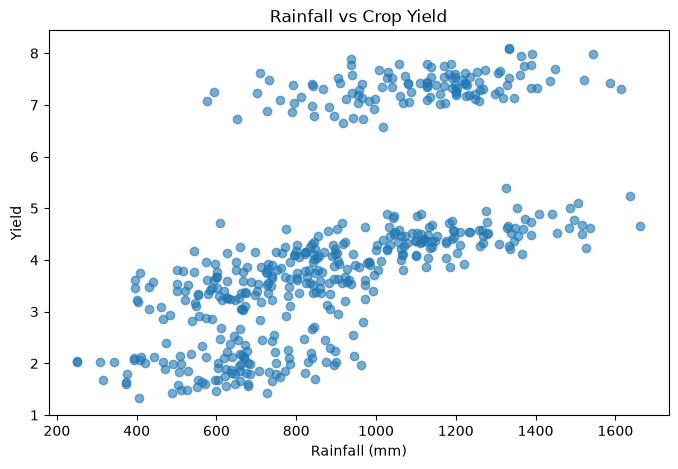

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["Rainfall"], df["Yield"], alpha=0.6)
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield")
plt.show()

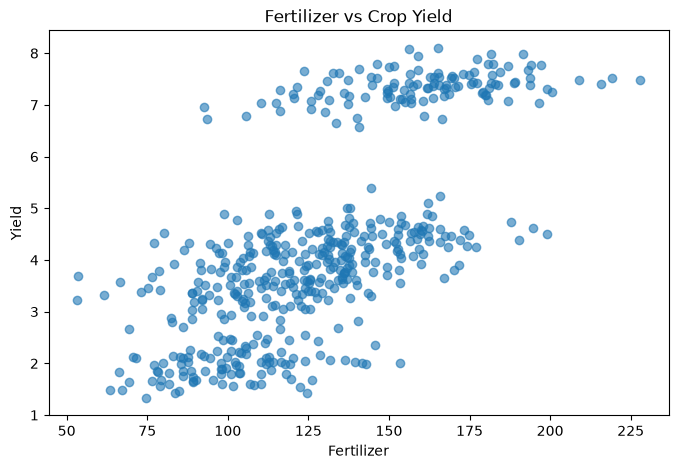

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fertilizer"], df["Yield"], alpha=0.6)
plt.title("Fertilizer vs Crop Yield")
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

## 7. Select Input Features and Target

In [10]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (500, 7)
Target shape: (500,)


## 8. Preprocessing

In [11]:
categorical_features = ["Crop", "State"]
numeric_features = ["Area", "Rainfall", "Temperature", "Fertilizer", "Pesticide"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 9. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


## 10. Linear Regression Model

In [13]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## 11. Evaluate Linear Regression

In [14]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R2  :", round(linear_r2, 4))

Linear Regression Results
MAE : 0.2049
RMSE: 0.251
R2  : 0.9818


## 12. Random Forest Model

In [15]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 13. Evaluate Random Forest

In [16]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R2  :", round(rf_r2, 4))

Random Forest Results
MAE : 0.2075
RMSE: 0.2621
R2  : 0.9802


## 14. Compare Models

In [17]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.204859,0.250980,0.981810
1,Random Forest,0.207508,0.262067,0.980167


## 15. Actual vs Predicted Yield

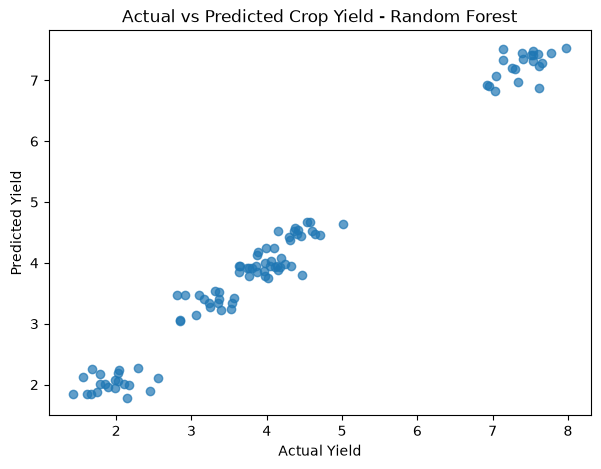

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_predictions, alpha=0.7)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield - Random Forest")
plt.show()

## 16. Predict Yield for New Data

In [19]:
new_data = pd.DataFrame({
    "Crop": ["Rice"],
    "State": ["Tamil Nadu"],
    "Area": [10],
    "Rainfall": [1200],
    "Temperature": [28],
    "Fertilizer": [150],
    "Pesticide": [18]
})

predicted_yield = rf_model.predict(new_data)

print("Predicted Crop Yield:", round(predicted_yield[0], 2))

Predicted Crop Yield: 4.47


## 17. Save the Trained Model

In [20]:
import joblib

joblib.dump(rf_model, "crop_yield_model.pkl")

print("Model saved as crop_yield_model.pkl")

Model saved as crop_yield_model.pkl
